Practical: Recurrent neural network (RNN) Use the Google stock prices dataset and design a time series analysis and prediction system using RNN.

In [1]:
# Importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout

In [3]:
# Load dataset
df = pd.read_csv('GOOG.csv', index_col='Date', parse_dates=['Date'])

In [4]:
# Keep only Close column
df = df[['Close']]
print(df.head())

                Close
Date                 
2004-08-23  54.495735
2004-08-24  52.239197
2004-08-25  52.802086
2004-08-26  53.753517
2004-08-27  52.876804


In [5]:
# Normalize data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df['Close'].values.reshape(-1, 1))

In [6]:
# Training data length (80%)
training_data_len = int(np.ceil(len(scaled_data) * 0.8))

In [7]:
# Prepare training data
train_data = scaled_data[0:training_data_len]

x_train = []
y_train = []

for i in range(60, len(train_data)):
    x_train.append(train_data[i-60:i, 0])
    y_train.append(train_data[i, 0])

In [8]:
# Convert to numpy arrays
x_train = np.array(x_train)
y_train = np.array(y_train)


In [9]:
# Reshape for LSTM
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))


In [10]:
# Build LSTM model
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(x_train.shape[1], 1)),
    Dropout(0.2),

    LSTM(50, return_sequences=True),
    Dropout(0.2),

    LSTM(50),
    Dropout(0.2),

    Dense(1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [11]:
# Compile model
model.compile(optimizer='adam', loss='mean_squared_error')

In [12]:
# Train model
model.fit(x_train, y_train, epochs=25, batch_size=32)

Epoch 1/25
102/102 ━━━━━━━━━━━━━━━━━━━━ 12s 76ms/step - loss: 0.0023
Epoch 2/25
102/102 ━━━━━━━━━━━━━━━━━━━━ 7s 70ms/step - loss: 5.7005e-04
Epoch 3/25
102/102 ━━━━━━━━━━━━━━━━━━━━ 11s 76ms/step - loss: 5.1623e-04
Epoch 4/25
102/102 ━━━━━━━━━━━━━━━━━━━━ 10s 78ms/step - loss: 4.3688e-04
Epoch 5/25
102/102 ━━━━━━━━━━━━━━━━━━━━ 7s 65ms/step - loss: 4.3997e-04
Epoch 6/25
102/102 ━━━━━━━━━━━━━━━━━━━━ 12s 78ms/step - loss: 4.6527e-04
Epoch 7/25
102/102 ━━━━━━━━━━━━━━━━━━━━ 8s 80ms/step - loss: 4.0455e-04
Epoch 8/25
102/102 ━━━━━━━━━━━━━━━━━━━━ 10s 101ms/step - loss: 3.7269e-04
Epoch 9/25
102/102 ━━━━━━━━━━━━━━━━━━━━ 18s 74ms/step - loss: 3.4399e-04
Epoch 10/25
102/102 ━━━━━━━━━━━━━━━━━━━━ 8s 77ms/step - loss: 3.5171e-04
Epoch 11/25
102/102 ━━━━━━━━━━━━━━━━━━━━ 10s 73ms/step - loss: 2.9325e-04
Epoch 12/25
102/102 ━━━━━━━━━━━━━━━━━━━━ 7s 68ms/step - loss: 2.7764e-04
Epoch 13/25
102/102 ━━━━━━━━━━━━━━━━━━━━ 9s 83ms/step - loss: 2.8412e-04
Epoch 14/25
102/102 ━━━━━━━━━━━━━━━━━━━━ 7s 65ms/step - 

In [13]:
# Prepare test data
test_data = scaled_data[training_data_len - 60:]

x_test = []
y_test = df.iloc[training_data_len:]['Close'].values

for i in range(60, len(test_data)):
    x_test.append(test_data[i-60:i, 0])

x_test = np.array(x_test)

In [14]:
# Reshape test data
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

In [15]:
# Predictions
predictions = model.predict(x_test)
predictions = scaler.inverse_transform(predictions)

26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step


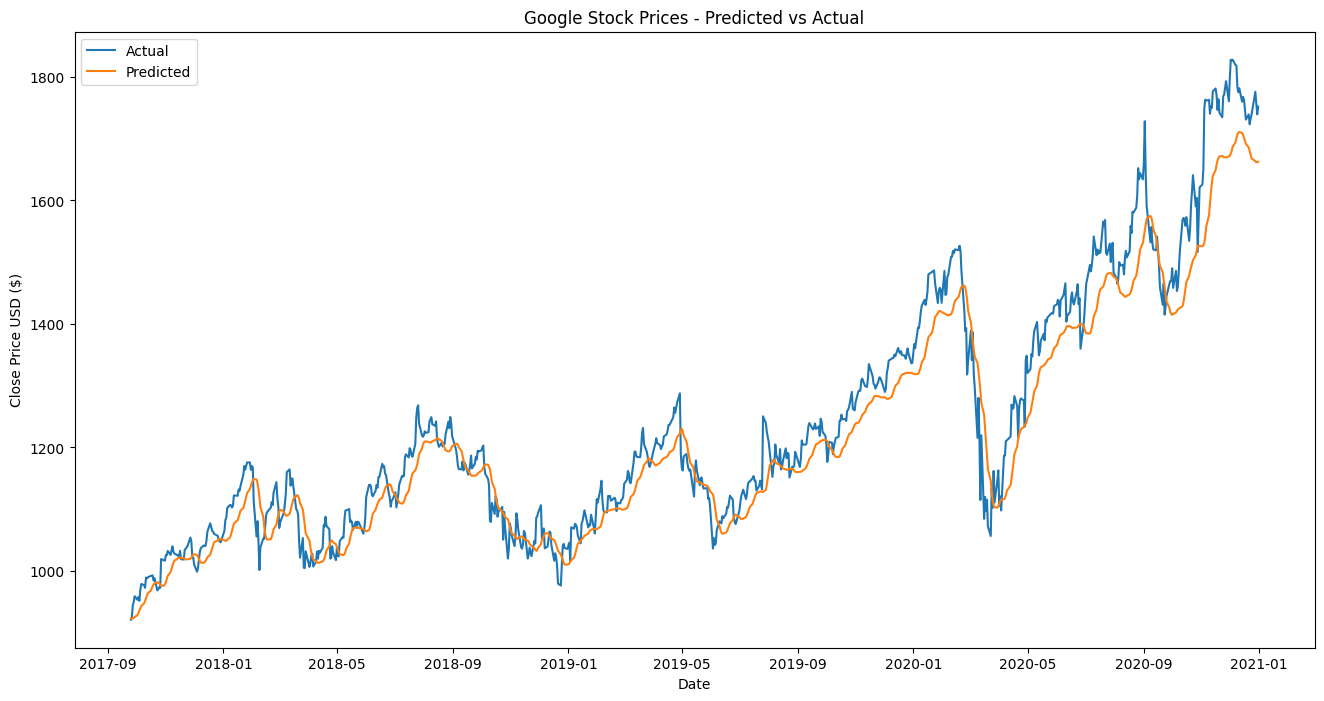

In [16]:
# Plot results
plt.figure(figsize=(16, 8))
plt.title('Google Stock Prices - Predicted vs Actual')

plt.plot(df.iloc[training_data_len:].index, y_test, label='Actual')
plt.plot(df.iloc[training_data_len:].index, predictions, label='Predicted')

plt.xlabel('Date')
plt.ylabel('Close Price USD ($)')
plt.legend()
plt.show()

In [18]:
!jupyter nbconvert --to html "/content/Recurrent_neural_network_(RNN).ipynb"

[NbConvertApp] Converting notebook /content/Recurrent_neural_network_(RNN).ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 1 image(s).
[NbConvertApp] Writing 449279 bytes to /content/Recurrent_neural_network_(RNN).html
